In [3]:
# Package imports
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import sklearn.datasets
import sklearn.linear_model
import matplotlib

# Display plots inline and change default figure size
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (10.0, 8.0)

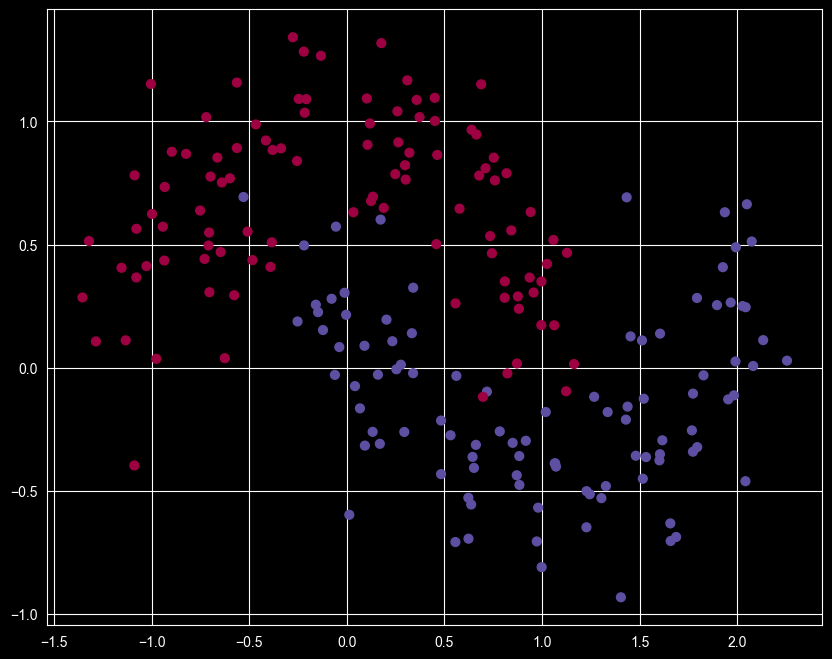

In [4]:
# Generate a dataset and plot it
import sklearn.datasets
import matplotlib.pyplot as plt

# Generazione dataset
np.random.seed(0)
X_raw, y_raw = sklearn.datasets.make_moons(200, noise=0.20)


X = X_raw.T
plt.scatter(X[0,:], X[1,:], s=40, c=y_raw, cmap=plt.cm.Spectral)

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(pred_func, X, y):
    """
    Parametri:
    - pred_func: funzione che accetta un input (X) e restituisce predizioni (0 o 1).
    - X: i dati di input (features).
    - y: le etichette reali (target).
    """
    # Impostiamo i limiti per la griglia
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.01 # Passo della griglia

    # Generiamo la griglia (mesh grid)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Prediciamo il valore per ogni punto della griglia
    # np.c_ concatena i punti per passarli alla funzione di predizione
    Z = pred_func(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Disegniamo il contorno colorato (la decision boundary)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)

    # Sovrapponiamo i punti reali del dataset
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral, edgecolors='k')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title("Decision Boundary")

Proviamo con la logistic regression


In [6]:
# Train the logistic regression classifier
clf = sklearn.linear_model.LogisticRegressionCV()
clf.fit(X_raw, y_raw)
# Calcolo dell'accuratezza
accuracy = clf.score(X_raw, y_raw)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 85.00%


C:\Users\andre\PycharmProjects\corso_ai\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\andre\PycharmProjects\corso_ai\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


Text(0.5, 1.0, 'Logistic Regression')

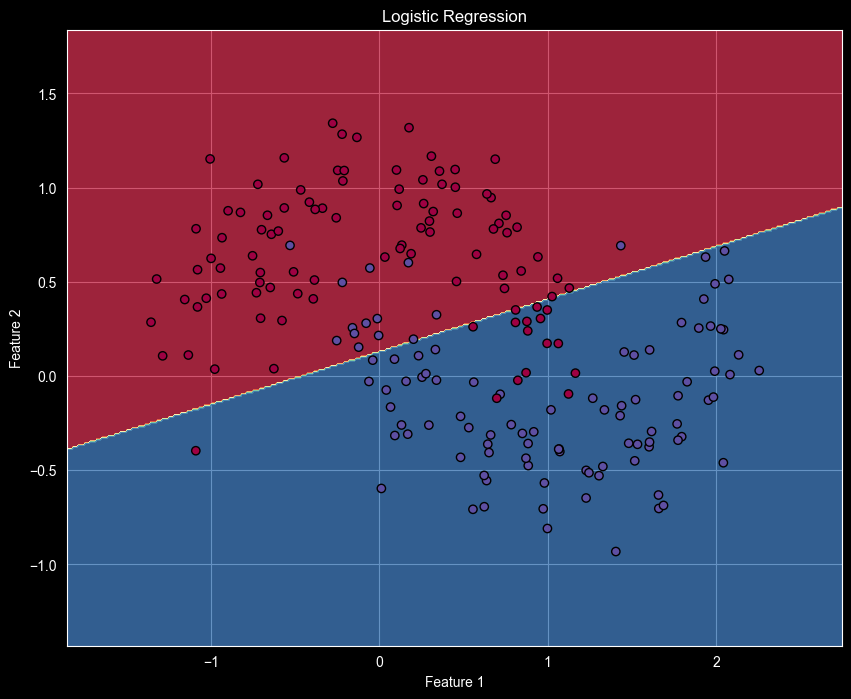

In [7]:
# Plot the decision boundary
plot_decision_boundary(lambda x: clf.predict(x), X_raw, y_raw)
plt.title("Logistic Regression")

Adesso costruiamo una rete neurale con un unico hidden layer con cinque neuroni
![Rete_Neurale.png](../Rete_Neurale.png)

In [109]:
import numpy as np

def tanh(z):
    """Funzione di attivazione per i layer nascosti."""
    return np.tanh(z)

def softmax(z):
    """Funzione di attivazione per l'output layer (classificazione multi-classe)."""
    # Sottraiamo il max per stabilità numerica (evita overflow degli esponenziali)
    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

def initialize_parameters(input_dim, num_layers, num_neurons, output_dim):
    """
    Inizializza i parametri per una rete con 5 neuroni per layer nascosto.
    """
    params = {}
    # Architettura: [Input(2), Hidden(5), ..., Hidden(5), Output(2)]
    dims = [input_dim] + [num_neurons] * num_layers + [output_dim]

    for l in range(1, len(dims)):
        # Inizializzazione di Xavier/Glorot (comune per tanh)
        params[f'W{l}'] = np.random.randn(dims[l], dims[l-1]) * np.sqrt(1 / dims[l-1])
        params[f'b{l}'] = np.zeros((dims[l], 1))

    return params

def forward_propagation_with_cache(X, params):
    cache = {"A0": X}
    L = len(params) // 2

    for l in range(1, L):
        Z = np.dot(params[f'W{l}'], cache[f'A{l-1}']) + params[f'b{l}']
        cache[f'Z{l}'] = Z
        cache[f'A{l}'] = tanh(Z)

    Z_final = np.dot(params[f'W{L}'], cache[f'A{L-1}']) + params[f'b{L}']
    cache[f'Z{L}'] = Z_final
    cache[f'A{L}'] = softmax(Z_final)

    return cache[f'A{L}'], cache

input_dim = 2
output_dim = 2
num_hidden_layers = 10
num_neurons = 50

# Test con un input casuale (2 feature, 1 esempio)
X_test = np.random.randn(input_dim, 1)
parametri = initialize_parameters(input_dim, num_hidden_layers, num_neurons,output_dim)
output,_ = forward_propagation_with_cache(X_test, parametri)

print("Probabilità di output (Softmax):")
print(output)
print(f"Somma delle probabilità: {np.sum(output)}") # Deve essere 1.0

Probabilità di output (Softmax):
[[0.44834933]
 [0.55165067]]
Somma delle probabilità: 1.0


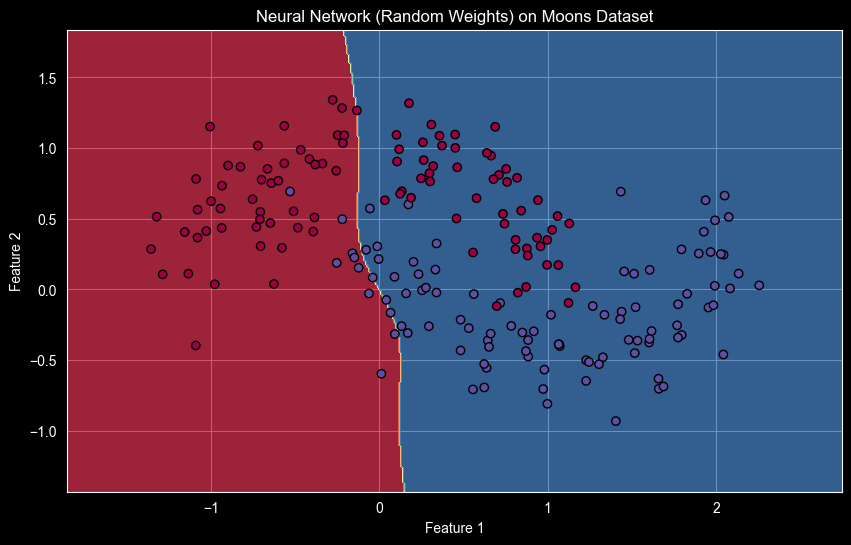

In [110]:
# Inizializziamo la rete con i parametri richiesti
# Input: 2 feature, 3 layer nascosti da 5 neuroni, Output: 2 classi
params = initialize_parameters(input_dim=2, num_layers=num_hidden_layers, num_neurons=num_neurons, output_dim=2)

def predict(x_grid):
    # x_grid arriva come (N, 2), lo trasponiamo per la rete
    a_final,_ = forward_propagation_with_cache(x_grid.T, params)
    # Prendiamo la classe con probabilità maggiore (argmax)
    return np.argmax(a_final, axis=0)

# Eseguiamo il plot
plt.figure(figsize=(10, 6))
plot_decision_boundary(predict, X_raw, y_raw)
plt.title("Neural Network (Random Weights) on Moons Dataset")
plt.show()

In [91]:
def backward_propagation(params, cache, Y):
    m = Y.shape[1]
    L = len(params) // 2
    grads = {}

    # 1. Errore sull'output layer (Softmax + Cross-Entropy)
    dZ = cache[f'A{L}'] - Y

    for l in range(L, 0, -1):
        # 2. Gradienti per i parametri del layer l
        grads[f'dW{l}'] = (1 / m) * np.dot(dZ, cache[f'A{l-1}'].T)
        grads[f'db{l}'] = (1 / m) * np.sum(dZ, axis=1, keepdims=True)

        # 3. Propagazione dell'errore al layer precedente (l-1)
        if l > 1:
            # Usiamo la derivata della tanh: (1 - A^2)
            dA_prev = np.dot(params[f'W{l}'].T, dZ)
            dZ = dA_prev * (1 - np.power(cache[f'A{l-1}'], 2))

    return grads

In [114]:
def train(X, Y, num_layers, num_neurons,epochs=1000, lr=0.1):
    params = initialize_parameters(input_dim=2, num_layers=num_layers, num_neurons=num_neurons,output_dim=2)

    for i in range(epochs):
        # Forward
        A_final, cache = forward_propagation_with_cache(X, params)

        # Backward
        grads = backward_propagation(params, cache, Y)

        # Update (Gradient Descent)
        for l in range(1, (len(params) // 2) + 1):
            params[f'W{l}'] -= lr * grads[f'dW{l}']
            params[f'b{l}'] -= lr * grads[f'db{l}']

        if i % 100 == 0:
            loss = -np.mean(Y * np.log(A_final + 1e-8)) # Cross-entropy
            print(f"Epoch {i}, Loss: {loss:.4f}")

    return params

def one_hot(y, num_classes):
    return np.eye(num_classes)[y].T

Y = one_hot(y_raw, 2) # Diventa (2, 200)
# Esecuzione
final_params = train(X, Y, num_layers=num_hidden_layers, num_neurons=num_neurons,epochs=4000, lr=0.1)

Epoch 0, Loss: 0.2987
Epoch 100, Loss: 0.0728
Epoch 200, Loss: 0.0567
Epoch 300, Loss: 0.0480
Epoch 400, Loss: 0.0431
Epoch 500, Loss: 0.0368
Epoch 600, Loss: 0.0318
Epoch 700, Loss: 0.0349
Epoch 800, Loss: 0.0274
Epoch 900, Loss: 0.0249
Epoch 1000, Loss: 0.0204
Epoch 1100, Loss: 0.0188
Epoch 1200, Loss: 0.0174
Epoch 1300, Loss: 0.0160
Epoch 1400, Loss: 0.0149
Epoch 1500, Loss: 0.0140
Epoch 1600, Loss: 0.0136
Epoch 1700, Loss: 0.0126
Epoch 1800, Loss: 0.0116
Epoch 1900, Loss: 0.0089
Epoch 2000, Loss: 0.0190
Epoch 2100, Loss: 0.0105
Epoch 2200, Loss: 0.0096
Epoch 2300, Loss: 0.0086
Epoch 2400, Loss: 0.0080
Epoch 2500, Loss: 0.0075
Epoch 2600, Loss: 0.0063
Epoch 2700, Loss: 0.0060
Epoch 2800, Loss: 0.0058
Epoch 2900, Loss: 0.0056
Epoch 3000, Loss: 0.0054
Epoch 3100, Loss: 0.0052
Epoch 3200, Loss: 0.0051
Epoch 3300, Loss: 0.0050
Epoch 3400, Loss: 0.0049
Epoch 3500, Loss: 0.0048
Epoch 3600, Loss: 0.0047
Epoch 3700, Loss: 0.0046
Epoch 3800, Loss: 0.0045
Epoch 3900, Loss: 0.0045


In [115]:
def predict(x_grid):
    # x_grid arriva come (N, 2), lo trasponiamo per la rete
    a_final,_ = forward_propagation_with_cache(x_grid.T, final_params)
    # Prendiamo la classe con probabilità maggiore (argmax)
    return np.argmax(a_final, axis=0)

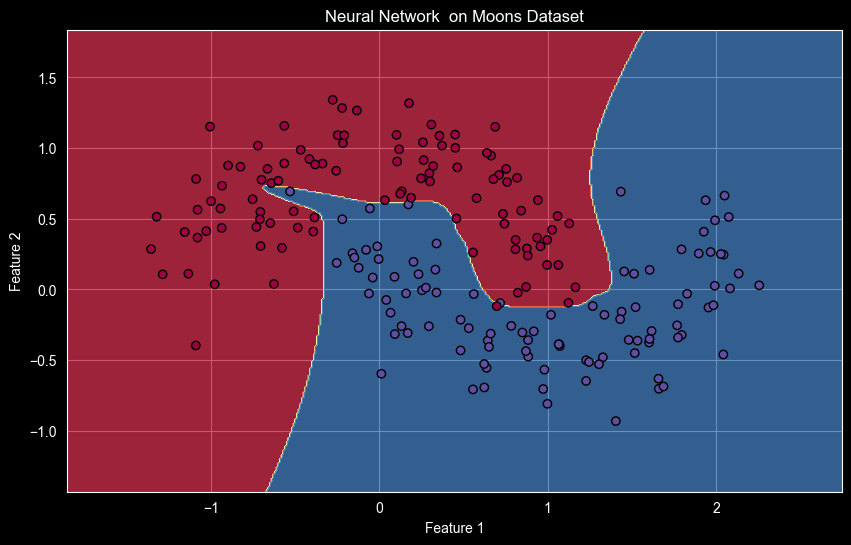

In [116]:
# Eseguiamo il plot
plt.figure(figsize=(10, 6))
plot_decision_boundary(predict, X_raw, y_raw)
plt.title("Neural Network  on Moons Dataset")
plt.show()

Adesso facciamo lo stesso training ma con pytorch

In [138]:
import torch
import torch.nn as nn
import torch.optim as optim

class MoonsModel(nn.Module):
    def __init__(self):
        super(MoonsModel, self).__init__()
        # Definiamo i layer come descritto: 3 hidden da 5 neuroni
        self.network = nn.Sequential(
            nn.Linear(2, 5),  # Input layer -> Hidden 1
            nn.Tanh(),        # Attivazione tanh [centrata sullo zero]
            nn.Linear(5, 5),  # Hidden 1 -> Hidden 2
            nn.Tanh(),
            nn.Linear(5, 5),  # Hidden 2 -> Hidden 3
            nn.Tanh(),
            nn.Linear(5, 2)   # Hidden 3 -> Output (2 classi)
            # Nota: CrossEntropyLoss di PyTorch include già il Softmax
        )

    def forward(self, x):
        # Esegue il forward pass calcolando le combinazioni lineari z [cite: 43]
        return self.network(x)

In [139]:
# 1. Convertiamo i dati in Tensor
X_tensor = torch.from_numpy(X_raw).float()
y_tensor = torch.from_numpy(y_raw).long()

# 2. Inizializziamo modello, funzione di costo e ottimizzatore
model = MoonsModel()
criterion = nn.CrossEntropyLoss() # Include Softmax e Log-Loss
optimizer = optim.SGD(model.parameters(), lr=0.5)

# 3. Training Loop
for epoch in range(4000):
    # Forward Pass
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)

    # Backward Pass (Autograd applica la chain rule automaticamente)
    optimizer.zero_grad() # Resetta i gradienti precedenti
    loss.backward()       # Calcola i nuovi gradienti
    optimizer.step()      # Aggiorna pesi e bias minimizzando la funzione di costo

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.6947
Epoch 200, Loss: 0.2792
Epoch 400, Loss: 0.1477
Epoch 600, Loss: 0.0853
Epoch 800, Loss: 0.0744
Epoch 1000, Loss: 0.0716
Epoch 1200, Loss: 0.0703
Epoch 1400, Loss: 0.0694
Epoch 1600, Loss: 0.0688
Epoch 1800, Loss: 0.0682
Epoch 2000, Loss: 0.0678
Epoch 2200, Loss: 0.0674
Epoch 2400, Loss: 0.0671
Epoch 2600, Loss: 0.0669
Epoch 2800, Loss: 0.0666
Epoch 3000, Loss: 0.0664
Epoch 3200, Loss: 0.0662
Epoch 3400, Loss: 0.0660
Epoch 3600, Loss: 0.0658
Epoch 3800, Loss: 0.0657


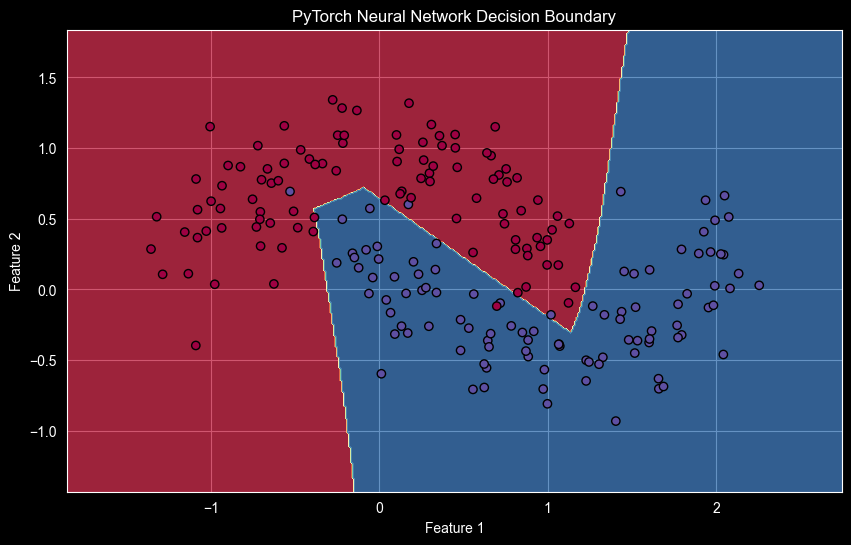

In [140]:
def predict_pytorch(x_grid):
    x_tensor = torch.from_numpy(x_grid).float()
    with torch.no_grad(): # Disabilita il tracciamento dei gradienti per il plotting
        outputs = model(x_tensor)
        # Applichiamo softmax per ottenere le probabilità e prendiamo l'argmax
        predictions = torch.softmax(outputs, dim=1)
        return torch.argmax(predictions, dim=1).numpy()

plt.figure(figsize=(10, 6))
plot_decision_boundary(predict_pytorch, X_raw, y_raw)
plt.title("PyTorch Neural Network Decision Boundary")
plt.show()

In [128]:
# Disabilitiamo il calcolo dei gradienti per la valutazione (risparmia memoria e calcolo)
with torch.no_grad():
    # 1. Otteniamo i logit (output grezzi) dal modello
    outputs = model(X_tensor)

    # 2. Trasformiamo i logit in predizioni di classe
    # Prendiamo l'indice del valore massimo lungo la dimensione delle classi (dim=1)
    _, predicted = torch.max(outputs, 1)

    # 3. Confrontiamo con le etichette reali
    correct = (predicted == y_tensor).sum().item()
    total = y_tensor.size(0)

    # 4. Calcoliamo la percentuale
    accuracy = correct / total

print(f"Accuratezza del modello PyTorch: {accuracy:.2%}")

Accuratezza del modello PyTorch: 99.00%
